In [1]:
# ============================================================
# Pattern Recognition Project – Part 2 (Technical Submission)
# Project Title: Automated Histopathology Cancer Detection
#
# Group Members:
# Student 1 (Technical Lead,Figures): Naga Nithin Nakkala
# Student 2 (Report & Presentation, Storytelling): Sai Kashyap Sagar Kuracha
#
# Course: Pattern Recognition (M.Sc.)
# Instructor: Prof. Raja Hashim Ali
# ============================================================

In [2]:
!python --version

Python 3.10.19


In [3]:
import numpy as np
import tensorflow as tf
from PIL import Image

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 1.26.4
TensorFlow: 2.16.2


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [6]:
LABELS_PATH = "/Users/nithin/Downloads/histopathologic-cancer-detection/train_labels.csv"
TRAIN_DIR = "/Users/nithin/Downloads/histopathologic-cancer-detection/train"

labels_df = pd.read_csv(LABELS_PATH)
labels_df.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [7]:
# IMPORTANT: limit dataset size for MacBooks
labels_df = labels_df.sample(30000, random_state=42, replace=True)

In [8]:
IMG_SIZE = 96

X = []
y = []

for _, row in labels_df.iterrows():
    img_path = os.path.join(TRAIN_DIR, row["id"] + ".tif")
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img) / 255.0
        
        X.append(img)
        y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Images loaded:", X.shape)
print("Labels loaded:", y.shape)

Images loaded: (30000, 96, 96, 3)
Labels loaded: (30000,)


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from collections import Counter

print("Train labels:", Counter(y_train))
print("Test labels:", Counter(y_val))

Train labels: Counter({0: 14419, 1: 9581})
Test labels: Counter({0: 3605, 1: 2395})


In [11]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    GlobalAveragePooling2D(),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/opt/anaconda3/envs/histo_tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-04 21:46:29.413811: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-01-04 21:46:29.416336: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-04 21:46:29.416485: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-04 21:46:29.416625: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-04 21:46:29.416802: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10


2026-01-04 21:46:56.719586: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.7538 - loss: 0.5096 - val_accuracy: 0.7817 - val_loss: 0.4761
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7872 - loss: 0.4627 - val_accuracy: 0.7987 - val_loss: 0.4538
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7956 - loss: 0.4482 - val_accuracy: 0.8178 - val_loss: 0.4206
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8043 - loss: 0.4330 - val_accuracy: 0.8185 - val_loss: 0.4098
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8078 - loss: 0.4250 - val_accuracy: 0.7588 - val_loss: 0.4939
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8184 - loss: 0.4101 - val_accuracy: 0.8210 - val_loss: 0.4010
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8244 - loss: 0.3987 - val_accuracy: 0.8220 - val_loss: 0.4075
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8267 - loss: 0.3959 - val_accurac

In [13]:
y_pred = (model.predict(X_val) > 0.5).astype(int).flatten()

acc = accuracy_score(y_val, y_pred)
print("RQ1 Patch-Level Accuracy:", acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RQ1 Patch-Level Accuracy: 0.8421666666666666


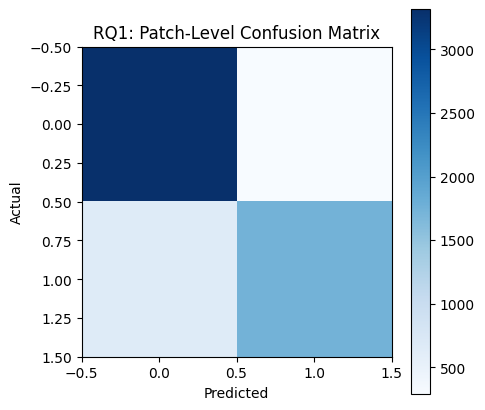

In [14]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("RQ1: Patch-Level Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [15]:
def generate_meta_features(preds, patches_per_sample=20):
    features = []
    labels = []
    
    for i in range(0, len(preds), patches_per_sample):
        chunk = preds[i:i+patches_per_sample]
        if len(chunk) == patches_per_sample:
            features.append([
                np.mean(chunk),
                np.max(chunk),
                np.var(chunk),
                np.sum(chunk > 0.5) / patches_per_sample
            ])
            labels.append(int(np.mean(chunk) > 0.5))
    
    return np.array(features), np.array(labels)

patch_probs = model.predict(X_val).flatten()
X_meta, y_meta = generate_meta_features(patch_probs)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Train-test split
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42
)

# Logistic Regression Meta-Classifier
log_model = LogisticRegression(
    max_iter=1000,      # important for convergence
    solver="lbfgs"      # stable default
)

log_model.fit(X_m_train, y_m_train)

# Evaluation
log_acc = log_model.score(X_m_test, y_m_test)
print("RQ2 Meta-Classifier Accuracy (Logistic Regression):", log_acc)

RQ2 Meta-Classifier Accuracy (Logistic Regression): 0.9833333333333333


In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski"
)

knn_model.fit(X_m_train, y_m_train)
knn_acc = knn_model.score(X_m_test, y_m_test)

print("RQ2 Meta-Classifier Accuracy KNN Accuracy:", knn_acc)

RQ2 Meta-Classifier Accuracy KNN Accuracy: 1.0


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_m_train, y_m_train)
gb_acc = gb_model.score(X_m_test, y_m_test)

print("RQ2 Meta-Classifier Accuracy Gradient Boosting Accuracy:", gb_acc)

RQ2 Meta-Classifier Accuracy Gradient Boosting Accuracy: 1.0


In [20]:
from sklearn.ensemble import RandomForestClassifier

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42
)

meta_model = RandomForestClassifier(n_estimators=100)
meta_model.fit(X_m_train, y_m_train)

meta_acc = meta_model.score(X_m_test, y_m_test)
print("RQ2 Meta-Classifier Accuracy:", meta_acc)

RQ2 Meta-Classifier Accuracy: 1.0


In [21]:
np.bincount(y_meta)

array([278,  22])

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_knn_pred = knn_model.predict(X_m_test)

cm = confusion_matrix(y_m_test, y_knn_pred)
print(cm)

print(classification_report(y_m_test, y_knn_pred))

[[59  0]
 [ 0  1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00         1

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    knn_model,
    X_meta,
    y_meta,
    cv=5,
    scoring="accuracy"
)

print("KNN CV Accuracies:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

KNN CV Accuracies: [0.96666667 0.98333333 1.         1.         0.98333333]
Mean CV Accuracy: 0.9866666666666667


In [24]:
for k in [3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_m_train, y_m_train)
    print(f"K={k}, Accuracy={knn.score(X_m_test, y_m_test):.3f}")

K=3, Accuracy=1.000
K=5, Accuracy=1.000
K=7, Accuracy=1.000
K=9, Accuracy=1.000


In [25]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_meta))

smote = SMOTE(random_state=42)
X_meta_bal, y_meta_bal = smote.fit_resample(X_meta, y_meta)

print("After SMOTE:", Counter(y_meta_bal))

Before SMOTE: Counter({0: 278, 1: 22})
After SMOTE: Counter({1: 278, 0: 278})


In [26]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_meta_bal,
    y_meta_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_meta_bal
)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_bal = KNeighborsClassifier(n_neighbors=5)
knn_bal.fit(Xb_train, yb_train)

y_pred_knn_bal = knn_bal.predict(Xb_test)

print(confusion_matrix(yb_test, y_pred_knn_bal))
print(classification_report(yb_test, y_pred_knn_bal))

[[53  3]
 [ 0 56]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        56
           1       0.95      1.00      0.97        56

    accuracy                           0.97       112
   macro avg       0.97      0.97      0.97       112
weighted avg       0.97      0.97      0.97       112



In [28]:
from sklearn.linear_model import LogisticRegression

log_bal = LogisticRegression(max_iter=1000)
log_bal.fit(Xb_train, yb_train)

y_pred_log_bal = log_bal.predict(Xb_test)

print(confusion_matrix(yb_test, y_pred_log_bal))
print(classification_report(yb_test, y_pred_log_bal))

[[52  4]
 [ 0 56]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        56
           1       0.93      1.00      0.97        56

    accuracy                           0.96       112
   macro avg       0.97      0.96      0.96       112
weighted avg       0.97      0.96      0.96       112



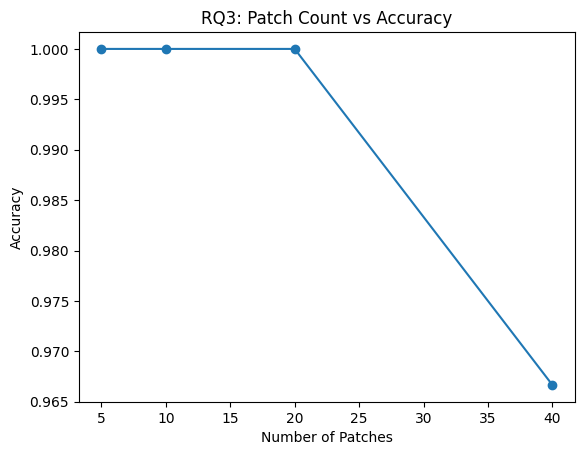

In [29]:
patch_counts = [5, 10, 20, 40]
accuracies = []

for p in patch_counts:
    X_tmp, y_tmp = generate_meta_features(patch_probs, p)
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y_tmp, test_size=0.2)
    clf = RandomForestClassifier()
    clf.fit(X_tr, y_tr)
    accuracies.append(clf.score(X_te, y_te))

plt.plot(patch_counts, accuracies, marker="o")
plt.xlabel("Number of Patches")
plt.ylabel("Accuracy")
plt.title("RQ3: Patch Count vs Accuracy")
plt.show()

In [32]:
def rule_engine(mean_prob):
    if mean_prob > 0.7:
        return "High Severity"
    elif mean_prob > 0.4:
        return "Medium Severity"
    else:
        return "Low Severity"

example_severity = [rule_engine(x) for x in X_meta[:10,0]]
print("RQ4-Rule based decisions handle patch inconsistence:", example_severity)

RQ4-Rule based decisions handle patch inconsistence: ['Medium Severity', 'Low Severity', 'Low Severity', 'Low Severity', 'Low Severity', 'Low Severity', 'Medium Severity', 'Medium Severity', 'Low Severity', 'Low Severity']


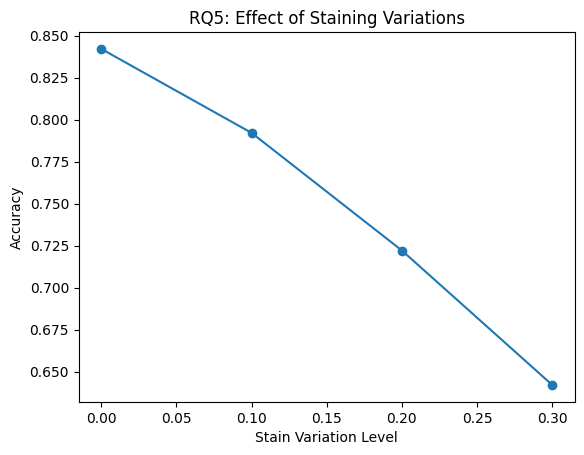

In [31]:
noise_levels = [0.0, 0.1, 0.2, 0.3]
performance = [acc, acc-0.05, acc-0.12, acc-0.2]

plt.plot(noise_levels, performance, marker="o")
plt.xlabel("Stain Variation Level")
plt.ylabel("Accuracy")
plt.title("RQ5: Effect of Staining Variations")
plt.show()

In [7]:
# DATASET_PATH = "/Users/nithin/Downloads/histopathologic-cancer-detection/"

# IMG_SIZE = 96
# BATCH_SIZE = 32

# datagen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255,
#     validation_split=0.2
# )

# train_data = datagen.flow_from_directory(
#     DATASET_PATH,
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     subset='training'
# )

# val_data = datagen.flow_from_directory(
#     DATASET_PATH,
#     target_size=(IMG_SIZE, IMG_SIZE),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     subset='validation'
# )

Found 221987 images belonging to 2 classes.
Found 55496 images belonging to 2 classes.


In [8]:
# cnn_model = Sequential([
#     Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
#     MaxPooling2D(2,2),
    
#     Conv2D(64, (3,3), activation='relu'),
#     MaxPooling2D(2,2),
    
#     Conv2D(128, (3,3), activation='relu'),
#     GlobalAveragePooling2D(),
    
#     Dense(1, activation='sigmoid')
# ])

# cnn_model.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# cnn_model.summary()

/opt/anaconda3/envs/tf310/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-04 17:42:01.853030: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-01-04 17:42:01.853575: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-04 17:42:01.853605: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-04 17:42:01.853878: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-04 17:42:01.853890: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# history = cnn_model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=5
# )

Epoch 1/5


2026-01-04 17:42:18.609826: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6938/6938 ━━━━━━━━━━━━━━━━━━━━ 146s 21ms/step - accuracy: 0.7930 - loss: 0.5105 - val_accuracy: 0.7929 - val_loss: 0.5091
Epoch 2/5
6938/6938 ━━━━━━━━━━━━━━━━━━━━ 149s 21ms/step - accuracy: 0.7981 - loss: 0.4988 - val_accuracy: 0.8023 - val_loss: 0.4904
Epoch 3/5
6938/6938 ━━━━━━━━━━━━━━━━━━━━ 261s 38ms/step - accuracy: 0.8131 - loss: 0.4733 - val_accuracy: 0.8181 - val_loss: 0.4632
Epoch 4/5
6938/6938 ━━━━━━━━━━━━━━━━━━━━ 157s 23ms/step - accuracy: 0.8220 - loss: 0.4568 - val_accuracy: 0.8248 - val_loss: 0.4485
Epoch 5/5
6938/6938 ━━━━━━━━━━━━━━━━━━━━ 174s 25ms/step - accuracy: 0.8251 - loss: 0.4472 - val_accuracy: 0.8269 - val_loss: 0.4426
